# Filter demo (Colab ready)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sitcv/cv-course2/blob/main/filter.ipynb)

Run next cell first on Colab. Download sample images from GitHub repo.

In [ ]:
# Colab setup: fetch sample images if missing
import os, urllib.request

BASE = "https://raw.githubusercontent.com/sitcv/cv-course2/main/"
for name in ["girl.jpg", "hawaii.jpg", "lena.png"]:
    if not os.path.exists(name):
        urllib.request.urlretrieve(BASE + name, name)
        print("downloaded", name)

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

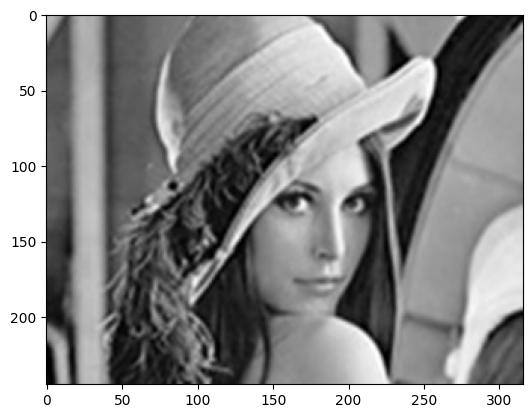

In [ ]:
#グレイ画像を読む
img = cv2.imread('girl.jpg')

#元画像を表示する
plt.imshow(img)

Text(0.5, 1.0, 'Averaging')

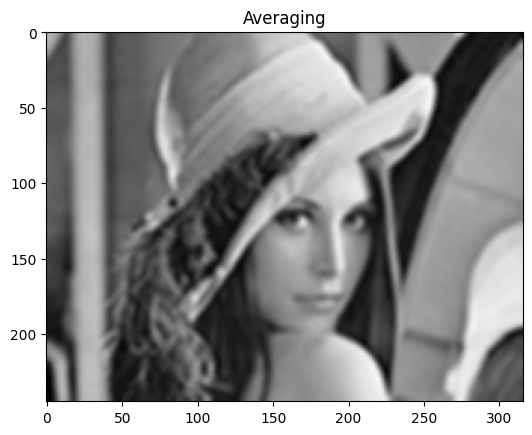

In [ ]:
# 平滑化
kernel = np.ones((5,5),np.float32)/25 #5x5平滑化フィルタのテンプレートを作成する
dst = cv2.filter2D(img,-1,kernel) #5x5平滑化フィルタを画像にかける
plt.imshow(dst) #平滑化した画像を表示する
plt.title('Averaging')

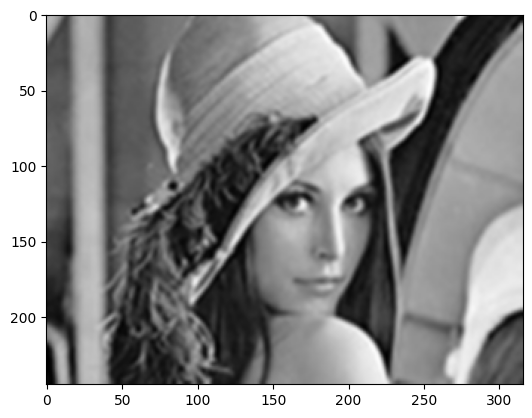

In [ ]:
# ガウシアンフィルタ
dst = cv2.GaussianBlur(img, (3, 3), -1)

# ガウシアンフィルタ後の画像表示
plt.imshow(dst)

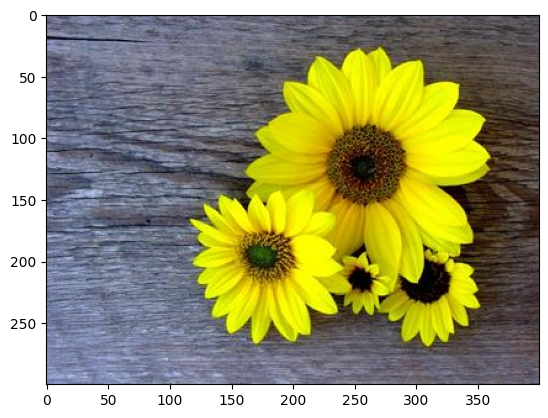

In [ ]:
img = cv2.imread('hawaii.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) ##注意： opencvが画像を読んだら、カラー成分はBGRになります。
#元画像を表示する
plt.imshow(img_rgb)

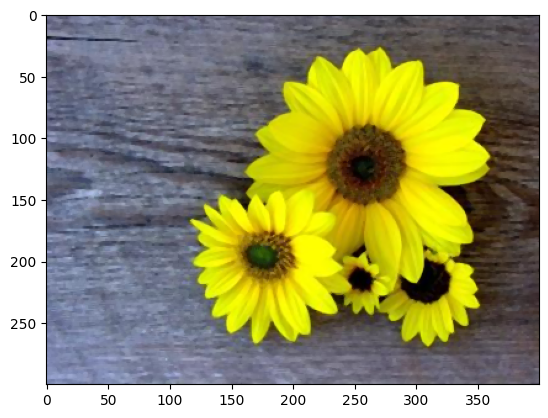

In [ ]:
#メディアンフィルタして表示する
dst = cv2.medianBlur(img_rgb, 3, -1)
plt.imshow(dst)

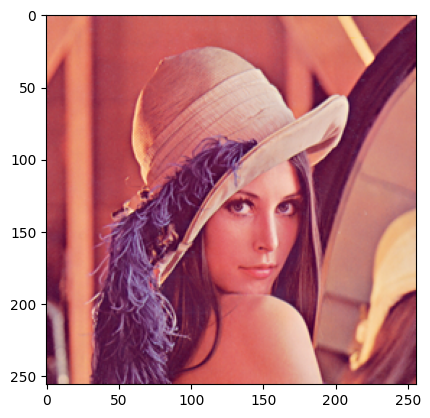

In [ ]:
img = cv2.imread("lena.png")

#CV2で読んだ画像データをRGB順にする
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) ##注意： opencvが画像を読んだら、カラー成分はBGRになります。

#画像を表示する
plt.imshow(img_rgb)

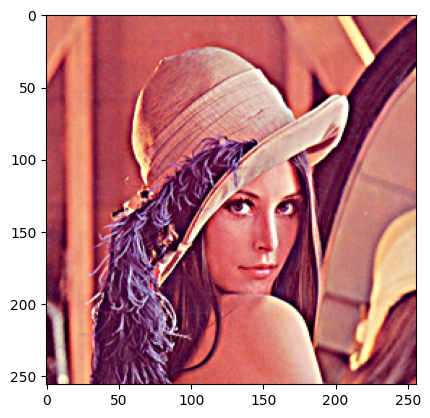

In [ ]:

#ガウシアンフィルタ
img_blurred = cv2.GaussianBlur(img_rgb, (11,11), 10)

#画像鮮鋭化と表示 ---元画像と比較して、画像が良くなった点か？
dst = cv2.addWeighted(img_rgb, 2, img_blurred, -1.0, 0)   # im1 = im + (im - im_blurred)=2*im - im_blurred
plt.imshow(dst)